# Diabetes Prediction - Machine Learning Project

## Objective
To predict whether a patient is diabetic or not based on 
medical diagnostic measurements using Machine Learning models.

## Dataset
- Source: Pima Indians Diabetes Database (Kaggle/UCI)
- 768 records, 9 features
- Target variable: Outcome (0 = No Diabetes, 1 = Diabetes)

### Importing the Dependencies

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Data collection and Analysis


In [5]:
df=pd.read_csv('diabetes.csv')

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.shape

(768, 9)

In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [9]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
cols_with_zeros=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

In [12]:
print(df[cols_with_zeros].eq(0).sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [13]:
for col in cols_with_zeros:
    df[col]=df[col].replace(0,df[col].median())

In [14]:
print(df[cols_with_zeros].eq(0).sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## Data Cleaning
- Dataset had no null values but contained hidden missing values
- Medical columns like Glucose, BloodPressure, BMI cannot be zero
- Found zeros in:
  - Glucose: 5 rows
  - BloodPressure: 35 rows
  - SkinThickness: 227 rows
  - Insulin: 374 rows
  - BMI: 11 rows
- Replaced all zeros with median values of respective columns

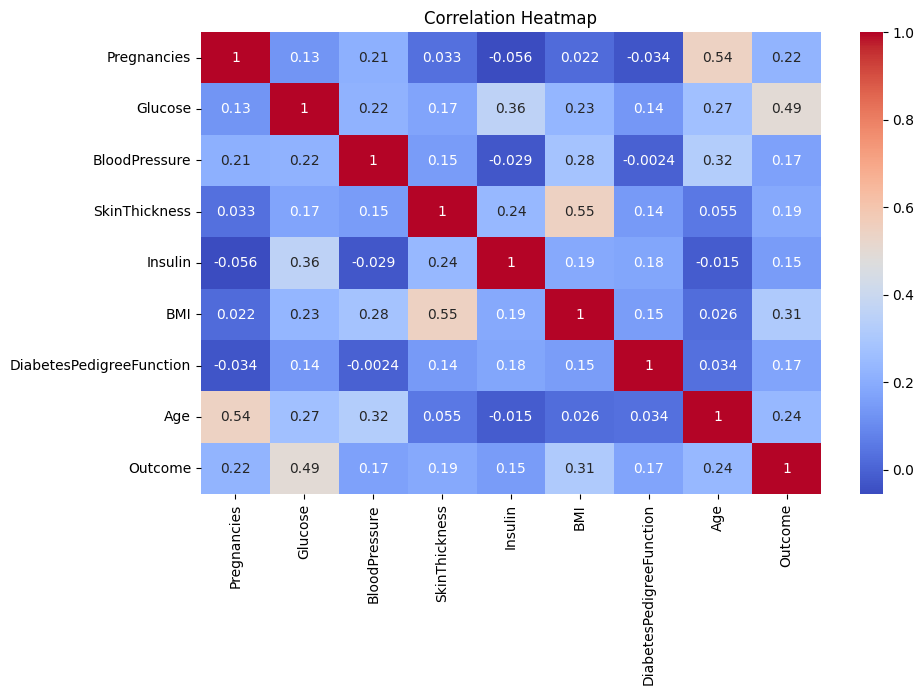

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Key EDA Findings
- Glucose is the strongest predictor of diabetes (correlation = 0.49)
- BMI shows moderate correlation with diabetes (0.31)
- Age and Pregnancies also positively correlate with diabetes


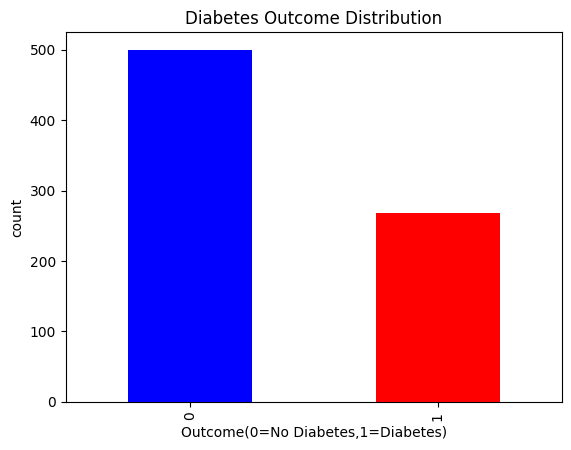

In [16]:
#sns.barplot(df['Outcome'].value_counts())
df['Outcome'].value_counts().plot(kind='bar',color=['blue','red'])
plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome(0=No Diabetes,1=Diabetes)')
plt.ylabel('count')
plt.show()

In [17]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Dataset has mild class imbalance:
  - No Diabetes (0): 500 patients (65%)
  - Diabetes (1): 268 patients (35%)

In [18]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred=model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nConfusion matrix:\n",confusion_matrix(y_test,y_pred))
print("\nClassification_report\n",classification_report(y_test,y_pred))

Accuracy: 0.7662337662337663

Confusion matrix:
 [[82 17]
 [19 36]]

Classification_report
               precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
y_pred_rf=rf_model.predict(X_test)

In [25]:
print("RandomForest Accuracy:",accuracy_score(y_test,y_pred_rf))

RandomForest Accuracy: 0.7662337662337663


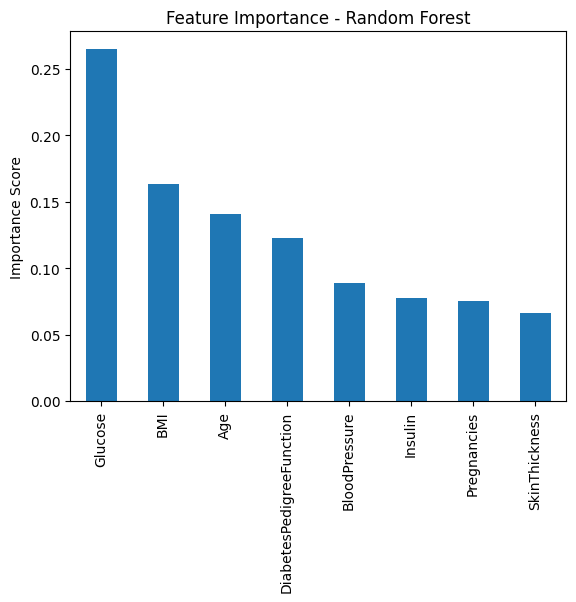

In [26]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=df.drop('Outcome', axis=1).columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance Score')
plt.show()

## Feature Importance - Random Forest
Top predictors of diabetes identified by Random Forest:
1. Glucose - 0.26 (most important)
2. BMI - 0.16
3. Age - 0.14
4. DiabetesPedigreeFunction - 0.12
5. BloodPressure - 0.09
6. Insulin - 0.08
7. Pregnancies - 0.07
8. SkinThickness - 0.07 (least important)

Both correlation analysis and feature importance 
consistently ranked Glucose as the strongest predictor.

In [27]:
from sklearn import svm
classifier = svm.SVC(kernel='linear')
classifier.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
X_test_prediction = classifier.predict(X_test)
print("accuracy_score on the testing data : ",accuracy_score(X_test_prediction,y_test))

accuracy_score on the testing data :  0.7662337662337663


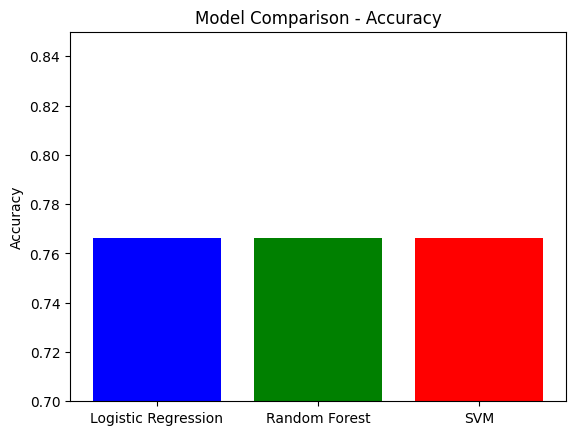

In [29]:
models = ['Logistic Regression', 'Random Forest', 'SVM']
accuracies = [0.7662, 0.7662, 0.7662]

plt.bar(models, accuracies, color=['blue', 'green', 'red'])
plt.title('Model Comparison - Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.85)
plt.show()

## Model Comparison
Three machine learning models were trained and evaluated:

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 76.6% |
| Random Forest | 76.6% |
| SVM | 76.6% |

All three models gave consistent accuracy of 76.6%.
This suggests the dataset has a performance ceiling 
around this range, possibly due to:
- Mild class imbalance
- Limited number of features
- Dataset size (768 rows)

### Making a Predictive System

In [31]:
import warnings
warnings.filterwarnings('ignore')

input_data=(4,110,92,0,0,37.6,0.191,30)

# changing the input data to numpy array
npy_array=np.asarray(input_data)

# reshape the array as we predicting for one instance
npy_reshaped=npy_array.reshape(1,-1)

#standardised the input data
std_data=scaler.transform(npy_reshaped)
print("standardized data:\n",std_data)

#prdiction
prediction=classifier.predict(std_data)
print(prediction)

if prediction[0]==0:
    print('person is NOT DIABETIC')
else:
    print('person is DIABETIC')

standardized data:
 [[ 0.07772963 -0.39253858  1.63534366 -3.07571613 -0.89868093  0.75783782
  -0.82647243 -0.25292759]]
[0]
person is NOT DIABETIC


In [32]:
import warnings
warnings.filterwarnings('ignore')

input_data=(5,166,72,19,175,25.8,0.587,51)

# changing the input data to numpy array
npy_array=np.asarray(input_data)

# reshape the array as we predicting for one instance
npy_reshaped=npy_array.reshape(1,-1)

#standardised the input data
std_data=scaler.transform(npy_reshaped)
print("standardized data:\n",std_data)

#prdiction
prediction=classifier.predict(std_data)
print(prediction)

if prediction[0]==0:
    print('person is NOT DIABETIC')
else:
    print('person is DIABETIC')

standardized data:
 [[ 0.37979288  1.46912301 -0.01899526 -0.91067031  0.74221198 -0.94491184
   0.35009487  1.57410227]]
[1]
person is DIABETIC


#### Predictive System
Built an end-to-end prediction system that takes a 
patient's medical data as input and predicts 
whether the person is diabetic or not.

### Output:if prediction list at 0th position is 0 then  Person is NOT DIABETIC else Person is DIABETIC

## Conclusion

This end-to-end machine learning project predicts diabetes 
risk based on medical diagnostic data.

### Key Findings:
1. GLUCOSE is the strongest predictor of diabetes
2. BMI and Age are second and third most important features
3. All three models achieved consistent accuracy of 76.6%
4. Dataset has mild class imbalance (65% vs 35%)

### Limitations:
- Dataset limited to female patients above 21 years
- Class imbalance affects model performance on diabetic cases
- Recall for diabetic class (0.65) needs improvement

### Future Improvements:
- Apply SMOTE to handle class imbalance
- Try XGBoost and Neural Networks
- Deploy model using Streamlit for real time prediction

### Predictive System:
Built an end-to-end prediction system that takes patient 
medical data as input and predicts diabetes risk in real time.